# 01 EDA

**Objetivo:** Foco en análisis exploratorio, carga de data/raw, limpieza usando src.preprocessing y guardado del set final en data/processed.

In [2]:
import sys
import os
import pandas as pd

# Agregar la ruta a la carpeta src para poder importar los módulos módulos desarrollados
sys.path.append(os.path.abspath('..'))


# Definición de rutas base a los archivos de datos 
RAW_DATA_PATH_1 = '../data/raw/BD_IPSA_1940.xlsx'
RAW_DATA_PATH_2 = '../data/raw/HISTORICO_SUERTES.xlsx'
PROCESSED_DATA_PATH = '../data/processed/datos_limpios_modelo.csv'


Se realizó un análisis exploratorio inicial de ambas bases de datos con el fin de comprender su estructura general y obtener un contexto previo sobre la información disponible. En esta etapa se revisó la dimensión de cada conjunto de datos, la cantidad de registros y variables, los tipos de datos presentes en cada columna, la existencia de valores nulos y una vista preliminar de los primeros registros. Este proceso permitió identificar las características de las variables utilizadas, evaluar la calidad de los datos y establecer una base sólida para las etapas posteriores de preprocesamiento, selección de variables y modelado

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df_reg = pd.read_excel('../data/raw/HISTORICO_SUERTES.xlsx')
df_clf = pd.read_excel('../data/raw/BD_IPSA_1940.xlsx')

# Vista general
print("REGRESIÓN")
print(df_reg.shape)
print(df_reg.info())
print(df_reg.head())

print("\nCLASIFICACIÓN")
print(df_clf.shape)
print(df_clf.info())
print(df_clf.head())

REGRESIÓN
(21027, 85)
<class 'pandas.DataFrame'>
RangeIndex: 21027 entries, 0 to 21026
Data columns (total 85 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Período                    21027 non-null  int64         
 1   Hacienda                   21027 non-null  int64         
 2   Nombre                     21027 non-null  str           
 3   Zona                       21027 non-null  str           
 4   Tenencia                   21026 non-null  float64       
 5   Suerte                     21027 non-null  str           
 6   Suelo                      17269 non-null  str           
 7   Area Neta                  21027 non-null  float64       
 8   Dist Km                    21022 non-null  float64       
 9   Variedad                   21027 non-null  str           
 10  Cod.Estado #               21027 non-null  int64         
 11  Cod.Estado                 21027 non-null  str          

A partir del análisis exploratorio realizado previamente, se identificó que el dataset de regresión contenía columnas completamente vacías, específicamente Fert.Nitrogen y Sum Oscilación Temp Ciclo. Dado que estas variables no contienen información (todos sus valores son nulos), se determinó que no aportan valor al modelo, por lo que fueron eliminadas del conjunto de datos.

Adicionalmente, en el dataset de clasificación se encontró la columna “Unnamed: 0”, la cual corresponde a un índice generado. Esta variable no tiene significado predictivo ni aporta información relevante para el análisis, por lo que también fue eliminada.

In [4]:
# Eliminar columnas totalmente vacías
df_reg = df_reg.dropna(axis=1, how='all')
df_clf = df_clf.dropna(axis=1, how='all')

# Eliminar columnas irrelevantes tipo índice
df_clf = df_clf.drop(columns=['Unnamed: 0'], errors='ignore')
df_reg = df_reg.drop(columns=['Unnamed: 0'], errors='ignore')

print("Columnas finales en regresión:", df_reg.shape[1])
print("Columnas finales en clasificación:", df_clf.shape[1])

Columnas finales en regresión: 83
Columnas finales en clasificación: 20


Una vez realizada una limpieza básica de los valores nulos, se procede a un análisis más detallado de la calidad de los datos. En esta etapa, se identifican las variables con una alta proporción de valores faltantes y aquellas con una cantidad manejable de datos nulos, con el objetivo de definir un tratamiento adecuado para cada caso

In [5]:
#Mostrar todas las variables 
pd.set_option('display.max_rows', None)

#Organizamos los valores nulos de forma descendente 
missing_reg = df_reg.isnull().mean().sort_values(ascending=False) * 100
missing_clf = df_clf.isnull().mean().sort_values(ascending=False) * 100

print("Porcentaje de valores faltantes - Regresión")
print(missing_reg)

print("\nPorcentaje de valores faltantes - Clasificación")
print(missing_clf)

Porcentaje de valores faltantes - Regresión
Urea 46%                   96.561564
NITRAX-S                   96.442669
MEZ                        95.382128
MicroZinc                  94.535597
Boro Granul.               93.888810
Sul.Amonio                 93.546393
NITO_XTEND                 82.503448
Vinaza                     80.510772
Temp. Media Ciclo          78.456271
Temp. Media 0-3            78.456271
Precipitacion 0_3          78.456271
Oscilacion Temp Med 0-3    78.456271
Humedad Rel Media Ciclo    78.456271
Temp Min Ciclo             78.456271
Humedad Rel Media 0-3      78.456271
Temp Max Ciclo             78.456271
Precipitacion Ciclo        78.456271
Radicion Solar 0-3         78.456271
Radiacion Solar Ciclo      78.456271
Oscilacion Temp Ciclo      78.456271
Evaporacion 0-3            78.456271
Evaporacion Ciclo          78.456271
%Infest.Diatrea            73.367575
Codigo Estacion            70.109859
D.S.                       65.910496
Num.Riegos                 59.8

Con el fin de obtener una visión más clara de la presencia de valores nulos, se generará un gráfico de barras que permita visualizar de manera más sencilla la cantidad de datos faltantes por variable. Esta representación facilita la interpretación y el análisis de la calidad de los datos.

Este procedimiento se realizará únicamente sobre el dataset de regresión, ya que en el análisis previo se evidenció que las variables del dataset de clasificación se encuentran completas y no presentan valores nulos. Por esta razón, el análisis gráfico de datos faltantes se enfocará exclusivamente en las variables asociadas al problema de regresión.

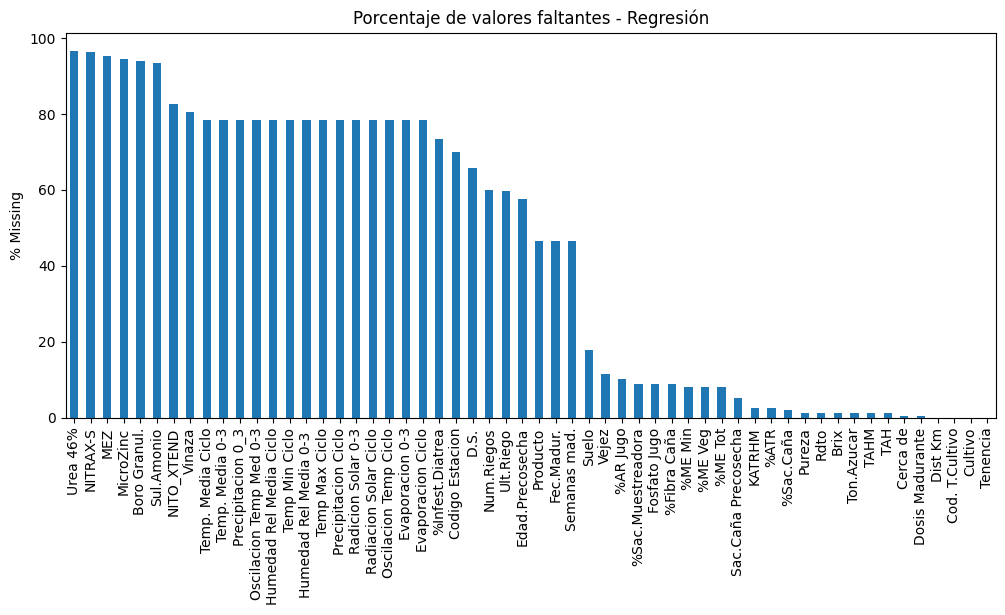

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

In [6]:
# Solo mostrar columnas con missing > 0 para no generar gráficas vacías
missing_reg_plot = missing_reg[missing_reg > 0]

plt.figure(figsize=(12, 5))
missing_reg_plot.plot(kind='bar')
plt.title('Porcentaje de valores faltantes - Regresión')
plt.ylabel('% Missing')
plt.show()

plt.figure(figsize=(12, 5))


### Analisis Detallado de la Base de Datos Historico de Suertes

A partir de la gráfica, se identificó con mayor claridad que varias variables del dataset de regresión presentan porcentajes de valores nulos entre el 80% y el 97%. Debido a este alto nivel de datos faltantes, se decidió descartar dichas variables, ya que la cantidad de información disponible es demasiado limitada para realizar una imputación confiable. En estos casos, aplicar medidas como la mediana podría no ser lo más adecuado, pues los pocos valores existentes podrían no representar de forma correcta el comportamiento real de la variable.

Además, se observó que gran parte de las columnas eliminadas corresponden a variables relacionadas con fertilizantes. Desde el contexto del negocio y del cultivo de caña de azúcar, estas variables podrían ser potencialmente importantes para explicar el rendimiento del cultivo. Sin embargo, desde el punto de vista estadístico, la gran cantidad de valores faltantes representa una limitación significativa, ya que impide extraer conclusiones confiables y podría introducir sesgos en el análisis. Por esta razón, como equipo se decidió eliminarlas, priorizando la calidad y consistencia de los datos disponibles.

Por otra parte, se observó que existen variables con porcentajes de valores nulos en un rango intermedio, aproximadamente entre el 50% y el 80%. Estas variables no serán descartadas de manera inmediata, sino que serán analizadas posteriormente con mayor detalle para determinar si resulta más conveniente eliminarlas o aplicar algún método de imputación, considerando tanto el comportamiento estadístico de los datos como su relevancia dentro del contexto del cultivo de caña de azúcar.

En cuanto al dataset de clasificación, no se evidencian problemas de valores nulos, ya que todas sus variables presentan un porcentaje de datos faltantes del 0%. Por ello, en este caso la limpieza y selección de variables no se basará en la ausencia de datos, sino principalmente en su relevancia dentro del contexto del problema y su posible aporte al modelo de clasificación.

In [7]:
#Eliminamos las variable con porcentaje de nullos mayor al 80%
cols_mayor_80 = missing_reg[missing_reg > 80].index
df_reg = df_reg.drop(columns=cols_mayor_80)

print("Columnas eliminadas:")
print(list(cols_mayor_80))
print("Nuevo número de columnas:", df_reg.shape[1])

Columnas eliminadas:
['Urea 46%', 'NITRAX-S', 'MEZ', 'MicroZinc', 'Boro Granul.', 'Sul.Amonio', 'NITO_XTEND', 'Vinaza']
Nuevo número de columnas: 75


Adicionalmente, dentro del dataset se identificó la presencia de variables que corresponden más a resultados obtenidos después de la extracción o procesamiento de la caña que a factores propios del proceso productivo en campo. Entre estas se encuentran variables como TCHM, RDTO, TAH, pureza, % fibra, entre otras.

Aunque estas variables pueden estar relacionadas con el rendimiento final, no representan condiciones iniciales ni factores explicativos directos del cultivo, sino más bien indicadores de resultado o variables derivadas de etapas posteriores al proceso de producción de la caña.

Debido a esto, para el dataset de regresión se decidió eliminarlas, ya que su inclusión podría generar sesgos en el análisis y afectar la correcta interpretación del modelo, al incorporar información que no corresponde a variables predictoras del proceso, sino a resultados asociados a la cosecha o al procesamiento posterior.

In [8]:
#Lista de variables a eliminar
cols_resultado = [
    'TCHM',
    'Ton.Azucar',
    'Rdto',
    'TAH',
    'TAHM',
    '%Sac.Muestreadora',
    '%ATR',
    'KATRHM',
    'Pureza',
    'Brix',
    '%Fibra Caña',
    '%AR Jugo',
    '%ME Min',
    '%ME Veg',
    '%ME Tot',
    'Sac.Caña Precosecha',
    'Fosfato Jugo',
    'Edad.Precosecha'
]


cols_presentes = [col for col in cols_resultado if col in df_reg.columns]

df_reg = df_reg.drop(columns=cols_presentes, errors='ignore')

print("Se eliminaron estas columnas:")
print(cols_presentes)
print("Total eliminadas:", len(cols_presentes))
print("Nuevo shape:", df_reg.shape)
print(df_reg.info())

Se eliminaron estas columnas:
['TCHM', 'Ton.Azucar', 'Rdto', 'TAH', 'TAHM', '%Sac.Muestreadora', '%ATR', 'KATRHM', 'Pureza', 'Brix', '%Fibra Caña', '%AR Jugo', '%ME Min', '%ME Veg', '%ME Tot', 'Sac.Caña Precosecha', 'Fosfato Jugo', 'Edad.Precosecha']
Total eliminadas: 18
Nuevo shape: (21027, 57)
<class 'pandas.DataFrame'>
RangeIndex: 21027 entries, 0 to 21026
Data columns (total 57 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Período                  21027 non-null  int64         
 1   Hacienda                 21027 non-null  int64         
 2   Nombre                   21027 non-null  str           
 3   Zona                     21027 non-null  str           
 4   Tenencia                 21026 non-null  float64       
 5   Suerte                   21027 non-null  str           
 6   Suelo                    17269 non-null  str           
 7   Area Neta                21027 non-null  float64   

Después de eliminar en el dataset de regresión las variables que representaban resultados y no factores predictivos, se continuará con la depuración de ambos conjuntos de datos eliminando variables identificadoras o de referencia. Estas columnas, como códigos, índices o identificadores de la caña, no aportan información relevante para el análisis, por lo que se excluirán para conservar únicamente variables útiles en la construcción de los modelos.

In [9]:
#Identificadores del dataset de regresion:
cols_identificadores = [
    'Hacienda',
    'Nombre',
    'Suerte',
    'Cod.Estado #',
    'Cod.Estado',
    'Cod. T.Cultivo',
    'Codigo Estacion',
    'Período'

]

df_reg = df_reg.drop(columns=cols_identificadores, errors='ignore')

print("Columnas identificadoras eliminadas:")
print(cols_identificadores)
print("Nuevo número de columnas en regresión:", df_reg.shape[1])
print(df_reg.info())


Columnas identificadoras eliminadas:
['Hacienda', 'Nombre', 'Suerte', 'Cod.Estado #', 'Cod.Estado', 'Cod. T.Cultivo', 'Codigo Estacion', 'Período']
Nuevo número de columnas en regresión: 49
<class 'pandas.DataFrame'>
RangeIndex: 21027 entries, 0 to 21026
Data columns (total 49 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Zona                     21027 non-null  str           
 1   Tenencia                 21026 non-null  float64       
 2   Suelo                    17269 non-null  str           
 3   Area Neta                21027 non-null  float64       
 4   Dist Km                  21022 non-null  float64       
 5   Variedad                 21027 non-null  str           
 6   F.Siembra                21027 non-null  datetime64[us]
 7   D.S.                     7168 non-null   str           
 8   Ult.Riego                8470 non-null   datetime64[us]
 9   Edad Ult Cos             21027 non-n

In [10]:
#Identificadores del dataset de clasificacion:
cols_identificadores_clf = [
    'NOME',
    'FAZ',
    'TAL'
]

df_clf = df_clf.drop(columns=cols_identificadores_clf, errors='ignore')

print("Columnas identificadoras eliminadas en clasificación:")
print(cols_identificadores_clf)
print("Nuevo número de columnas en clasificación:", df_clf.shape[1])
print(df_clf.info())

Columnas identificadoras eliminadas en clasificación:
['NOME', 'FAZ', 'TAL']
Nuevo número de columnas en clasificación: 17
<class 'pandas.DataFrame'>
RangeIndex: 2187 entries, 0 to 2186
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   tipocorte       2187 non-null   str    
 1   variedad        2187 non-null   str    
 2   madurada        2187 non-null   str    
 3   producto        2187 non-null   str    
 4   dosismad        2187 non-null   float64
 5   semsmad         2187 non-null   float64
 6   edad            2187 non-null   float64
 7   cortes          2187 non-null   int64  
 8   me              2187 non-null   float64
 9   vejez           2187 non-null   float64
 10  sacarosa        2187 non-null   float64
 11  mes             2187 non-null   int64  
 12  periodo         2187 non-null   int64  
 13  TCH             2187 non-null   int64  
 14  lluvias         2187 non-null   int64  
 15  grupo_tenen

Una vez eliminadas las variables totalmente vacías o con muchos valores nulos, los identificadores y aquellas que correspondían a resultados o mediciones posteriores al proceso productivo, se volvió a calcular y graficar el porcentaje de valores faltantes. Esta segunda revisión permitió centrarse únicamente en las variables realmente candidatas para el modelado.

Con apoyo de la gráfica de missing values y del contexto del negocio, se analizaron las variables que aún conservaban porcentajes altos de valores nulos, especialmente las relacionadas con condiciones climáticas y de manejo agronómico. A partir de ello, se definió cuáles variables podían conservarse, cuáles requerían estrategias de imputación y cuáles debían descartarse por el alto nivel de incertidumbre que introducirían en el modelo.

In [11]:
#Mostrar todas las variables 
pd.set_option('display.max_rows', None)

#Organizamos los valores nulos de forma descendente 
missing_reg = df_reg.isnull().mean().sort_values(ascending=False) * 100


print("Porcentaje de valores faltantes - Regresión")
print(missing_reg)


Porcentaje de valores faltantes - Regresión
Oscilacion Temp Med 0-3    78.456271
Precipitacion 0_3          78.456271
Precipitacion Ciclo        78.456271
Temp. Media Ciclo          78.456271
Temp. Media 0-3            78.456271
Humedad Rel Media 0-3      78.456271
Humedad Rel Media Ciclo    78.456271
Temp Min Ciclo             78.456271
Temp Max Ciclo             78.456271
Evaporacion 0-3            78.456271
Evaporacion Ciclo          78.456271
Radicion Solar 0-3         78.456271
Radiacion Solar Ciclo      78.456271
Oscilacion Temp Ciclo      78.456271
%Infest.Diatrea            73.367575
D.S.                       65.910496
Num.Riegos                 59.870643
Ult.Riego                  59.718457
Producto                   46.502116
Fec.Madur.                 46.487849
Semanas mad.               46.487849
Suelo                      17.872259
Vejez                      11.627907
%Sac.Caña                   2.135350
Cerca de                    0.599230
Dosis Madurante             0.4

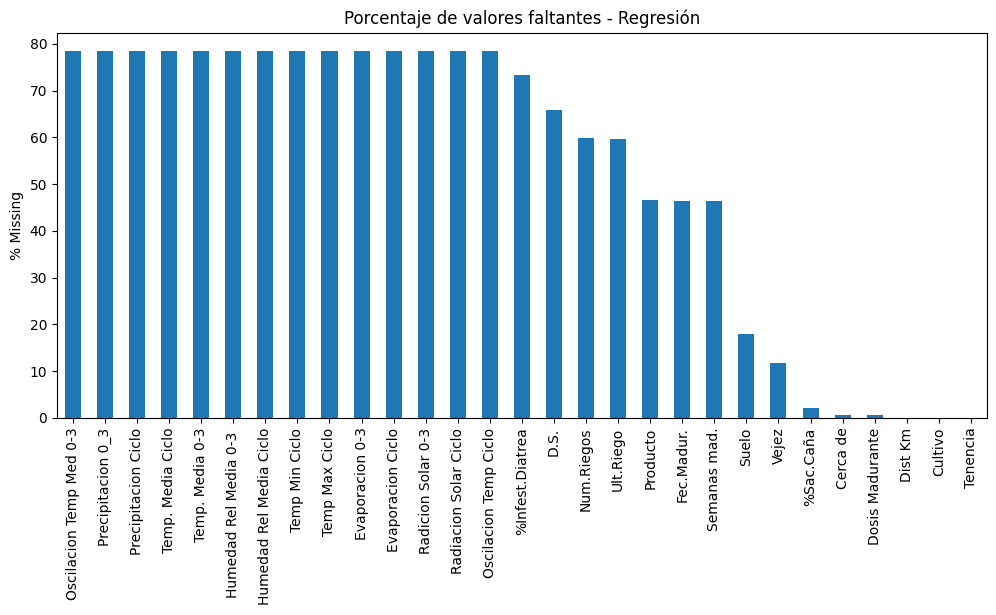

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

In [12]:
missing_reg_plot = missing_reg[missing_reg > 0]

plt.figure(figsize=(12, 5))
missing_reg_plot.plot(kind='bar')
plt.title('Porcentaje de valores faltantes - Regresión')
plt.ylabel('% Missing')
plt.show()

plt.figure(figsize=(12, 5))


Se eliminaron las variables climáticas relacionadas con temperatura, humedad, radiación, evaporación y precipitación, ya que presentaban alrededor de 78% de valores faltantes. Aunque estas variables pueden influir en el rendimiento y la calidad de la caña, imputar una cantidad tan alta de datos habría sido poco confiable.

Esto se debe a que las variables climáticas no son estables ni uniformes, sino que cambian según la zona y el momento del ciclo del cultivo. Por ello, completar artificialmente la mayor parte de sus valores podría generar sesgos en el modelo y alejar el análisis de las condiciones reales del cultivo.

Ademas en el caso de %Infest.Diatrea, aunque corresponde a una variable agronómica potencialmente relevante, se excluyó del modelo base por presentar una alta proporción de datos ausentes. Además, no fue posible asegurar que la ausencia del dato equivaliera a ausencia de infestación, por lo que una imputación con cero podía introducir sesgos en el análisis.

In [13]:
cols_descartar_final = missing_reg[missing_reg > 75].index

df_reg = df_reg.drop(columns=cols_descartar_final, errors='ignore')

print("Columnas eliminadas por tener más de 75% de valores faltantes:")
print(list(cols_descartar_final))
print("Nuevo número de columnas:", df_reg.shape[1])
print(df_reg.info())


Columnas eliminadas por tener más de 75% de valores faltantes:
['Oscilacion Temp Med 0-3', 'Precipitacion 0_3', 'Precipitacion Ciclo', 'Temp. Media Ciclo', 'Temp. Media 0-3', 'Humedad Rel Media 0-3 ', 'Humedad Rel Media Ciclo', 'Temp Min Ciclo', 'Temp Max Ciclo', 'Evaporacion 0-3', 'Evaporacion Ciclo', 'Radicion Solar 0-3', 'Radiacion Solar Ciclo', 'Oscilacion Temp Ciclo']
Nuevo número de columnas: 35
<class 'pandas.DataFrame'>
RangeIndex: 21027 entries, 0 to 21026
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Zona                    21027 non-null  str           
 1   Tenencia                21026 non-null  float64       
 2   Suelo                   17269 non-null  str           
 3   Area Neta               21027 non-null  float64       
 4   Dist Km                 21022 non-null  float64       
 5   Variedad                21027 non-null  str           
 6   F.Siembra   

Durante la depuración del dataset de regresión se eliminaron inicialmente las variables D.S., Producto y Cosechó, ya que no aportaban un valor predictivo claro al modelo. En el caso de D.S., no se contaba con suficiente claridad sobre su significado y además presentaba una alta proporción de datos faltantes. La variable Producto mostraba categorías inconsistentes y redundancia parcial con otras variables de maduración más estructuradas, mientras que Cosechó correspondía principalmente a códigos internos de operación, sin una relación agronómica directa con las variables objetivo.

Asimismo, se excluyeron Num.Riegos y Ult.Riego debido a su alto porcentaje de valores faltantes y a la dificultad de imputarlas de forma confiable. En particular, Ult.Riego, al ser una fecha, no podía completarse de manera metodológicamente adecuada, y en Num.Riegos asumir valores de cero habría sido una imputación poco sustentada. En contraste, se conservaron M3 Riego y DDUlt.Riego, ya que ambas presentaban información completa y representaban de manera más útil el manejo hídrico del cultivo.

También se compararon Fec.Madur. y Semanas mad., observándose que ambas compartían exactamente el mismo patrón de valores faltantes: cuando una tenía dato, la otra también, y cuando una estaba ausente, la otra igualmente. Esto indicó que ambas provenían del mismo proceso de registro asociado a la maduración del cultivo. Por esta razón, se decidió conservar Semanas mad., por ser una variable más directa e interpretable, y eliminar Fec.Madur., ya que correspondía a una fecha cruda que requería transformaciones adicionales.

FFinalmente, se descartaron las variables Zona, Cerca de, Tenencia y Suelo. Aunque estas variables podían estar asociadas indirectamente a diferencias productivas entre lotes, no se contaba con información complementaria suficiente para interpretar de manera adecuada las condiciones específicas representadas por sus categorías. En el caso particular de Suelo, además, se consideró que el análisis se encuentra centrado en cultivos ubicados en el Valle del Cauca, una región relativamente homogénea dentro del contexto cañero colombiano, lo que reduce parcialmente la variabilidad esperada en este tipo de condición. En consecuencia, su inclusión habría dificultado la explicación del modelo y la interpretación agronómica de los resultados, por lo que se priorizaron variables con una relación más directa y mejor sustentada con el proceso productivo de la caña de azúcar.

In [14]:
cols_descartar = [
    'D.S.',
    'Producto',
    'Cosechó',
    'Num.Riegos',
    'Ult.Riego',
    'Fec.Madur.',
    'Cerca de',
    'Tenencia',
    'Zona',
    'Suelo'
]

df_reg = df_reg.drop(columns=cols_descartar, errors='ignore')

print("Columnas eliminadas hasta ahora:")
print(cols_descartar)
print("Nuevo número de columnas:", df_reg.shape[1])

print(df_reg.info())

Columnas eliminadas hasta ahora:
['D.S.', 'Producto', 'Cosechó', 'Num.Riegos', 'Ult.Riego', 'Fec.Madur.', 'Cerca de', 'Tenencia', 'Zona', 'Suelo']
Nuevo número de columnas: 25
<class 'pandas.DataFrame'>
RangeIndex: 21027 entries, 0 to 21026
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Area Neta               21027 non-null  float64       
 1   Dist Km                 21022 non-null  float64       
 2   Variedad                21027 non-null  str           
 3   F.Siembra               21027 non-null  datetime64[us]
 4   Edad Ult Cos            21027 non-null  float64       
 5   F.Ult.Corte             21027 non-null  datetime64[us]
 6   Destino 1=Semilla       21027 non-null  int64         
 7   Cultivo                 21025 non-null  str           
 8   Dosis Madurante         20923 non-null  float64       
 9   Semanas mad.            11252 non-null  float64       
 10  T

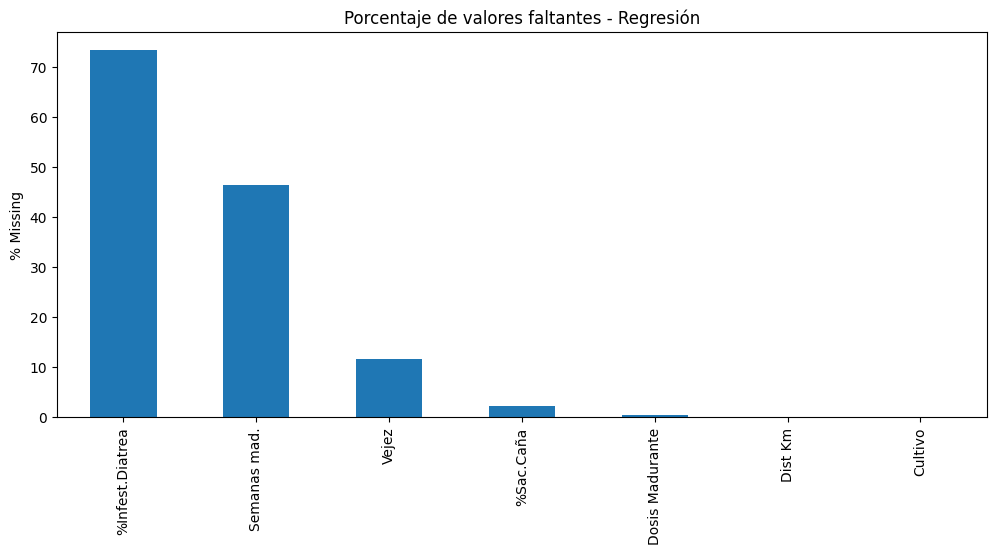

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

In [15]:
missing_reg = df_reg.isnull().mean().sort_values(ascending=False) * 100

missing_reg_plot = missing_reg[missing_reg > 0]

plt.figure(figsize=(12, 5))
missing_reg_plot.plot(kind='bar')
plt.title('Porcentaje de valores faltantes - Regresión')
plt.ylabel('% Missing')
plt.show()

plt.figure(figsize=(12, 5))

Sospechamos que la variable lluvia ciclo corresponde a la suma de las demás variables de lluvia. Por ello, vamos a verificar si esta hipótesis es correcta. En caso de confirmarla, optaremos por conservar únicamente las variables de lluvia por etapas, ya que estas podrían contener la misma información de forma más desagregada

In [16]:
#Copiamos dataset con las variables 
df_lluvia_check = df_reg[[
    'Lluvias Ciclo',
    'Lluvias 0 -3',
    'Lluvias tres a seis',
    'Lluvias seis a nueve',
    'Luvias 9 -FC'
]].copy()

#Realizamos la suma para comprobar sospechas
df_lluvia_check['suma_tramos'] = (
    df_lluvia_check['Lluvias 0 -3'] +
    df_lluvia_check['Lluvias tres a seis'] +
    df_lluvia_check['Lluvias seis a nueve'] +
    df_lluvia_check['Luvias 9 -FC']
)

#Revisamos
print(df_lluvia_check[['Lluvias Ciclo', 'suma_tramos']].head(20))
print(df_lluvia_check[['Lluvias Ciclo', 'suma_tramos']].corr())

    Lluvias Ciclo  suma_tramos
0          1038.0       1038.0
1             0.0          0.0
2          1002.0       1002.0
3             0.0          0.0
4           991.0        991.0
5           847.0        847.0
6          1261.0       1261.0
7          1002.0       1002.0
8             0.0          0.0
9             0.0          0.0
10          684.0        684.0
11         1269.0       1269.0
12            0.0          0.0
13            0.0          0.0
14            0.0          0.0
15            0.0          0.0
16          950.0        950.0
17          730.0        730.0
18         1038.0       1038.0
19          847.0        847.0
               Lluvias Ciclo  suma_tramos
Lluvias Ciclo       1.000000     0.999998
suma_tramos         0.999998     1.000000


Confirmamos nuestra teoría, por lo que procedemos a eliminar la variable lluvia ciclo, ya que representa la suma de las demás variables de lluvia.

In [17]:
cols_descartar = ['Lluvias Ciclo']

df_reg = df_reg.drop(columns=cols_descartar, errors='ignore')

print("Nuevo número de columnas:", df_reg.shape[1])

print(df_reg.info()) #Preguntar acerca de la variable vejez que es porque esos datos

Nuevo número de columnas: 24
<class 'pandas.DataFrame'>
RangeIndex: 21027 entries, 0 to 21026
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Area Neta               21027 non-null  float64       
 1   Dist Km                 21022 non-null  float64       
 2   Variedad                21027 non-null  str           
 3   F.Siembra               21027 non-null  datetime64[us]
 4   Edad Ult Cos            21027 non-null  float64       
 5   F.Ult.Corte             21027 non-null  datetime64[us]
 6   Destino 1=Semilla       21027 non-null  int64         
 7   Cultivo                 21025 non-null  str           
 8   Dosis Madurante         20923 non-null  float64       
 9   Semanas mad.            11252 non-null  float64       
 10  TonUltCorte             21027 non-null  float64       
 11  TCH                     21027 non-null  float64       
 12  %Sac.Caña               2057

Una vez finalizada la etapa de depuración y selección inicial de variables, el dataset de regresión quedó conformado por un conjunto de variables con mayor sentido agronómico y potencial explicativo sobre el rendimiento (TCH) y la calidad de la caña (%Sac.Caña). A partir de este punto, el análisis continúa con una fase más orientada a la exploración estadística y relacional de los datos, con el fin de identificar patrones, distribuciones, posibles outliers y relaciones entre variables predictoras y variables objetivo.

No obstante, antes de avanzar al análisis exploratorio profundo, aún se mantienen algunas dudas sobre variables específicas, especialmente aquellas relacionadas con fechas y con el tipo de suelo. En el caso de las fechas, variables como F.Siembra y F.Ult.Corte podrían contener información temporal útil, pero también podrían resultar redundantes frente a variables ya derivadas como Edad Ult Cos. Por su parte, Suelo conserva importancia desde el contexto agronómico, aunque será necesario evaluar con mayor detalle su comportamiento, su nivel de completitud y la manera en que sus categorías se relacionan con el rendimiento y la sacarosa. Por ello, estas variables serán observadas con especial atención en la siguiente fase del análisis.

Lo primero que haremos es tomar decision de como vamos a imputar algunas variables.

Los valores nulos de las variables dosis de madurante y porcentaje de Diatraea serán imputados con 0, asumiendo que en esos cultivos no hubo presencia registrada de bacterias ni aplicación de madurante.”

In [18]:
sys.path.append(os.path.abspath('..'))

from src.preprocessing import imputar_por_regla_negocio

df_reg = imputar_por_regla_negocio(
    df_reg,
    cols_cero=['Dosis Madurante', '%Infest.Diatrea'],
    cols_no_aplica=[]
)


print(df_reg[['Dosis Madurante', '%Infest.Diatrea']].isnull().sum())
print(df_reg[['Dosis Madurante', '%Infest.Diatrea']].head(20))


Dosis Madurante    0
%Infest.Diatrea    0
dtype: int64
    Dosis Madurante  %Infest.Diatrea
0               1.0           0.0000
1               0.0           0.0000
2               1.1           0.0000
3               0.0           0.0000
4               0.0           0.0000
5               1.0           1.8861
6               1.3           0.0000
7               1.1           0.0000
8               0.0           0.0000
9               0.0           0.0000
10              0.0           0.0000
11              0.0           8.9981
12              0.0           0.0000
13              0.0           0.0000
14              0.0           0.0000
15              0.0           0.0000
16              0.0           0.0000
17              1.2           0.0000
18              1.0           1.6393
19              1.0           1.4626


Para la variable Dist KM, se utilizará la mediana para imputar los valores nulos, ya que son aproximadamente cinco registros faltantes. En el caso de la variable cultivo, al ser una variable categórica con categorías como orgánico o normal, se imputará utilizando la moda

In [19]:
df_reg['Dist Km'] = df_reg['Dist Km'].fillna(df_reg['Dist Km'].median())
df_reg['Cultivo'] = df_reg['Cultivo'].fillna(df_reg['Cultivo'].mode()[0])

print(df_reg[['Dist Km', 'Cultivo']].isnull().sum())

Dist Km    0
Cultivo    0
dtype: int64


In [20]:
print(df_reg.info()) 

<class 'pandas.DataFrame'>
RangeIndex: 21027 entries, 0 to 21026
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Area Neta               21027 non-null  float64       
 1   Dist Km                 21027 non-null  float64       
 2   Variedad                21027 non-null  str           
 3   F.Siembra               21027 non-null  datetime64[us]
 4   Edad Ult Cos            21027 non-null  float64       
 5   F.Ult.Corte             21027 non-null  datetime64[us]
 6   Destino 1=Semilla       21027 non-null  int64         
 7   Cultivo                 21027 non-null  str           
 8   Dosis Madurante         21027 non-null  float64       
 9   Semanas mad.            11252 non-null  float64       
 10  TonUltCorte             21027 non-null  float64       
 11  TCH                     21027 non-null  float64       
 12  %Sac.Caña               20578 non-null  float64       
 1

En el caso de %Sac.Caña, al tratarse de una variable objetivo del problema de regresión, no se consideró apropiado imputar sus valores faltantes. Dado que los registros ausentes representaban una proporción baja del total, se optó por excluir únicamente esas filas en el momento de construir el modelo correspondiente, evitando así introducir valores artificiales en la variable que se desea predecir.

In [21]:
#Aqui toca ver que tecnica es mejor si imputarlo o elimarlo aqui voy hacer eliminar y luego 
#probamos imputar 

df_reg_sacarosa = df_reg.dropna(subset=['%Sac.Caña']).copy()

print("Shape original:", df_reg.shape)
print("Shape sin nulos en %Sac.Caña:", df_reg_sacarosa.shape)
print("Registros eliminados:", df_reg.shape[0] - df_reg_sacarosa.shape[0])

print(df_reg_sacarosa.info()) 


Shape original: (21027, 24)
Shape sin nulos en %Sac.Caña: (20578, 24)
Registros eliminados: 449
<class 'pandas.DataFrame'>
Index: 20578 entries, 0 to 20974
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Area Neta               20578 non-null  float64       
 1   Dist Km                 20578 non-null  float64       
 2   Variedad                20578 non-null  str           
 3   F.Siembra               20578 non-null  datetime64[us]
 4   Edad Ult Cos            20578 non-null  float64       
 5   F.Ult.Corte             20578 non-null  datetime64[us]
 6   Destino 1=Semilla       20578 non-null  int64         
 7   Cultivo                 20578 non-null  str           
 8   Dosis Madurante         20578 non-null  float64       
 9   Semanas mad.            11162 non-null  float64       
 10  TonUltCorte             20578 non-null  float64       
 11  TCH                     20

### Graficas de Distribucion de variables objetivos del dataset Historico de suertes

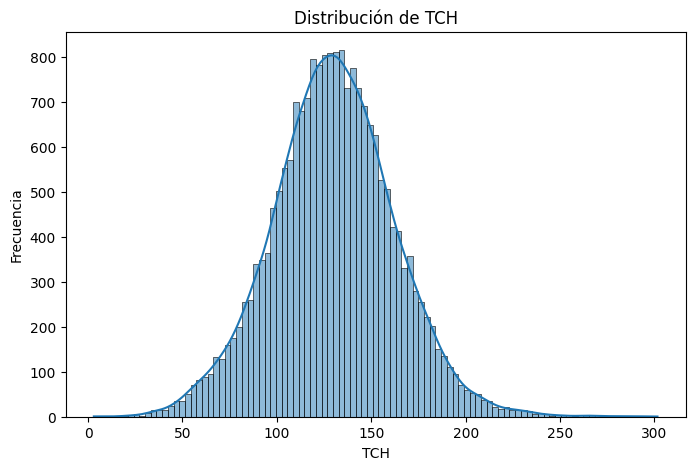

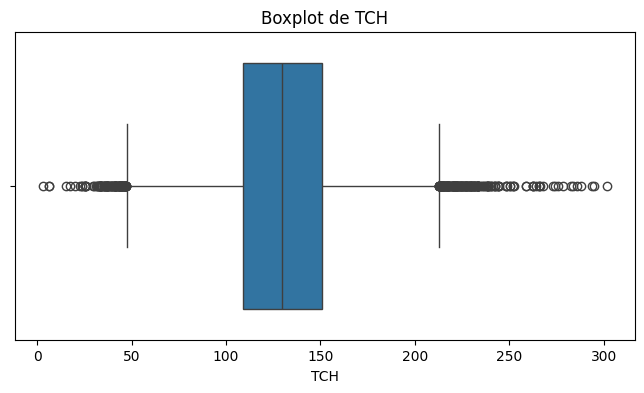

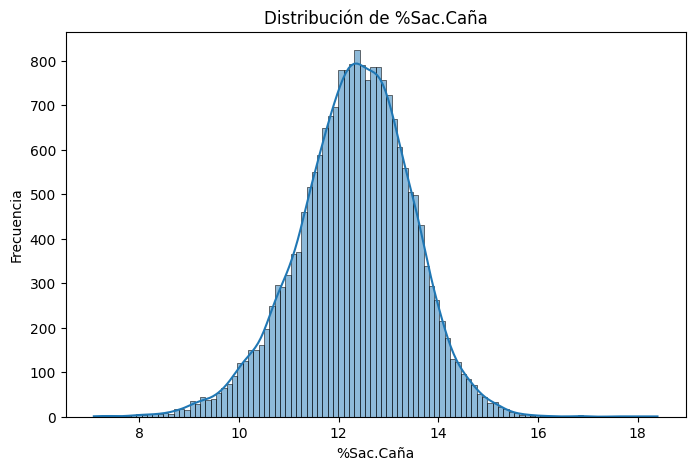

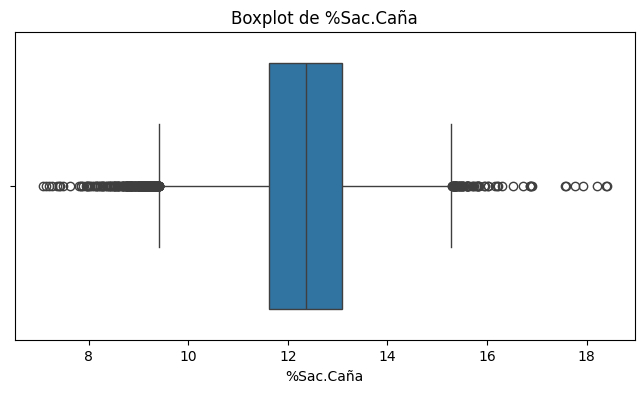

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df_reg_sacarosa['TCH'], kde=True)
plt.title('Distribución de TCH')
plt.xlabel('TCH')
plt.ylabel('Frecuencia')
plt.show()

# Boxplot TCH
plt.figure(figsize=(8,4))
sns.boxplot(x=df_reg_sacarosa['TCH'])
plt.title('Boxplot de TCH')
plt.xlabel('TCH')
plt.show()

# Histograma %Sac.Caña
plt.figure(figsize=(8,5))
sns.histplot(df_reg_sacarosa['%Sac.Caña'], kde=True)
plt.title('Distribución de %Sac.Caña')
plt.xlabel('%Sac.Caña')
plt.ylabel('Frecuencia')
plt.show()

# Boxplot %Sac.Caña
plt.figure(figsize=(8,4))
sns.boxplot(x=df_reg_sacarosa['%Sac.Caña'])
plt.title('Boxplot de %Sac.Caña')
plt.xlabel('%Sac.Caña')
plt.show()

In [23]:
stats_resumen = pd.DataFrame({
    'TCH': [
        df_reg_sacarosa['TCH'].mean(),
        df_reg_sacarosa['TCH'].median(),
        df_reg_sacarosa['TCH'].min(),
        df_reg_sacarosa['TCH'].max(),
        df_reg_sacarosa['TCH'].quantile(0.01),
        df_reg_sacarosa['TCH'].quantile(0.05),
        df_reg_sacarosa['TCH'].quantile(0.25),
        df_reg_sacarosa['TCH'].quantile(0.50),
        df_reg_sacarosa['TCH'].quantile(0.75),
        df_reg_sacarosa['TCH'].quantile(0.95),
        df_reg_sacarosa['TCH'].quantile(0.99),
    ],
    '%Sac.Caña': [
        df_reg_sacarosa['%Sac.Caña'].mean(),
        df_reg_sacarosa['%Sac.Caña'].median(),
        df_reg_sacarosa['%Sac.Caña'].min(),
        df_reg_sacarosa['%Sac.Caña'].max(),
        df_reg_sacarosa['%Sac.Caña'].quantile(0.01),
        df_reg_sacarosa['%Sac.Caña'].quantile(0.05),
        df_reg_sacarosa['%Sac.Caña'].quantile(0.25),
        df_reg_sacarosa['%Sac.Caña'].quantile(0.50),
        df_reg_sacarosa['%Sac.Caña'].quantile(0.75),
        df_reg_sacarosa['%Sac.Caña'].quantile(0.95),
        df_reg_sacarosa['%Sac.Caña'].quantile(0.99),
    ]
}, index=[
    'Media', 'Mediana', 'Mínimo', 'Máximo',
    'P1', 'P5', 'P25', 'P50', 'P75', 'P95', 'P99'
])

print(stats_resumen)

                TCH  %Sac.Caña
Media    130.029833  12.320202
Mediana  129.770210  12.370650
Mínimo     3.055379   7.086000
Máximo   301.608000  18.400000
P1        53.758831   9.304885
P5        76.367360  10.329955
P25      109.219883  11.619000
P50      129.770210  12.370650
P75      150.563464  13.087500
P95      182.800732  14.064915
P99      210.689285  14.849153


La variable TCH presenta una media de 130.03 y una mediana de 129.77, lo que sugiere una distribución relativamente centrada. Sin embargo, sus valores extremos van desde 3.06 hasta 301.61, y los percentiles muestran que la mayor parte de los registros se concentra por debajo de 210.69, lo que indica la presencia de outliers en ambos extremos.

En el caso de %Sac.Caña, la media (12.32) y la mediana (12.37) también son muy cercanas, lo que refleja una distribución equilibrada y menos dispersa que la de TCH. Sus valores se encuentran más concentrados, con el 99% de los datos por debajo de 14.85, aunque se observan algunos registros extremos que alcanzan 18.40.

### Correlacion de variables numericas

                             TCH  %Sac.Caña
TCH                     1.000000  -0.168060
TonUltCorte             0.316029   0.049519
Edad Ult Cos            0.280524   0.059867
Luvias 9 -FC            0.153096  -0.090607
%Infest.Diatrea         0.100283   0.024854
DDUlt.Riego             0.096214   0.026555
M3 Riego                0.088029  -0.035955
Area Neta               0.086959   0.113064
Lluvias seis a nueve    0.072360  -0.053331
Lluvias (2 Meses Ant.)  0.065856  -0.156232
Lluvias tres a seis     0.033038  -0.071276
Semanas mad.            0.027372   0.043971
Destino 1=Semilla       0.008525  -0.006877
Lluvias 0 -3           -0.003344  -0.026195
Dosis Madurante        -0.028546   0.288457
Dist Km                -0.062320   0.048014
Vejez                  -0.107558  -0.061062
%Sac.Caña              -0.168060   1.000000


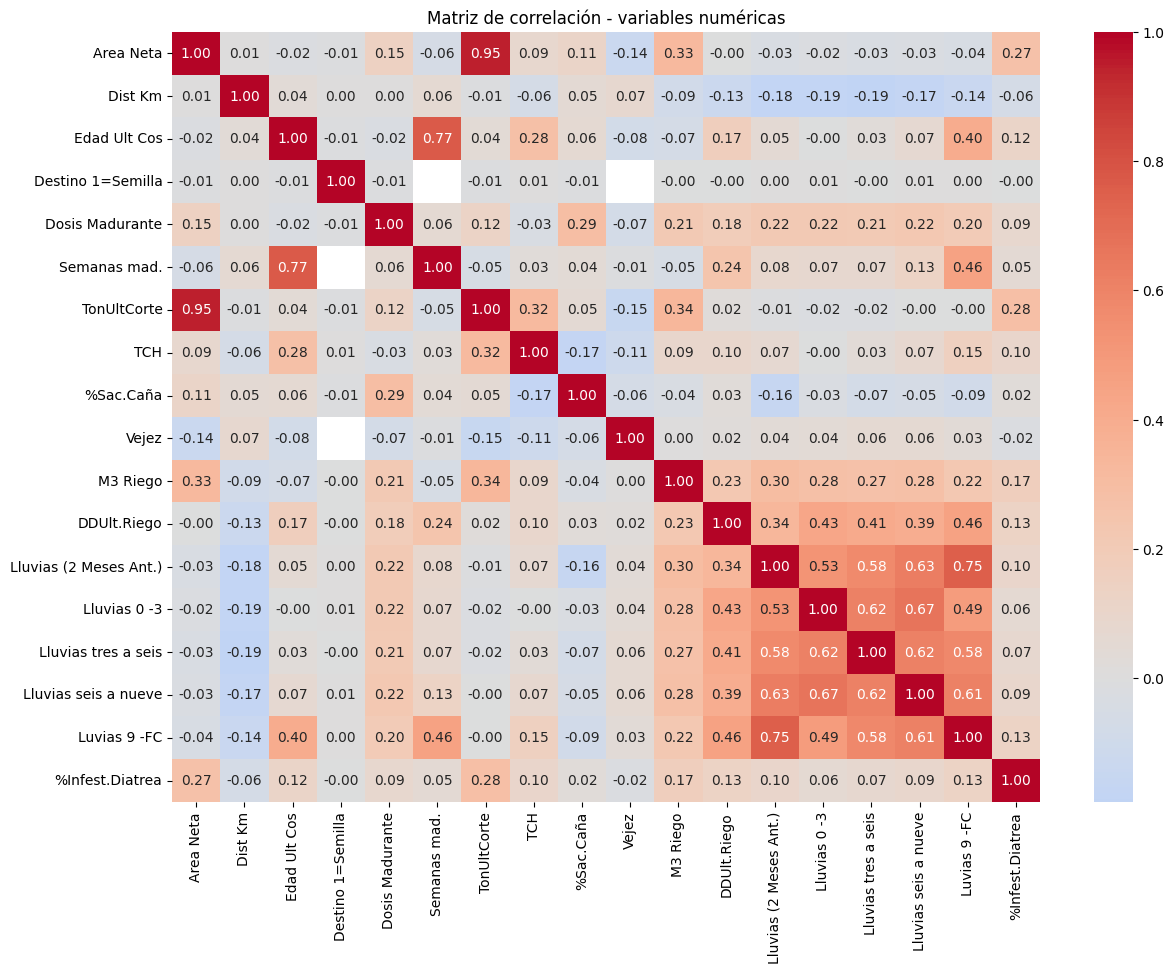

In [24]:
cols_num = [
    'Area Neta',
    'Dist Km',
    'Edad Ult Cos',
    'Destino 1=Semilla',
    'Dosis Madurante',
    'Semanas mad.',
    'TonUltCorte',
    'TCH',
    '%Sac.Caña',
    'Vejez',
    'M3 Riego',
    'DDUlt.Riego',
    'Lluvias (2 Meses Ant.)',
    'Lluvias 0 -3',
    'Lluvias tres a seis',
    'Lluvias seis a nueve',
    'Luvias 9 -FC',
    '%Infest.Diatrea'
]

corr_matrix = df_reg_sacarosa[cols_num].corr(numeric_only=True)
print(corr_matrix[['TCH', '%Sac.Caña']].sort_values(by='TCH', ascending=False))

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación - variables numéricas')
plt.show()

La matriz de correlación mostró que no existen relaciones lineales fuertes entre una sola variable predictora y las variables objetivo, lo cual es esperable en un problema agrícola donde el rendimiento y la calidad del cultivo dependen de múltiples factores que interactúan entre sí. No obstante, se identificaron asociaciones moderadas y coherentes con el contexto del negocio. En el caso de TCH, las variables con mayor relación fueron TonUltCorte y Edad Ult Cos, mientras que para %Sac.Caña destacó Dosis Madurante, además de relaciones negativas con variables de lluvia reciente. Estos resultados sugieren que el comportamiento de las variables objetivo no depende de un solo factor aislado, sino de combinaciones de variables agronómicas, climáticas y de manejo.

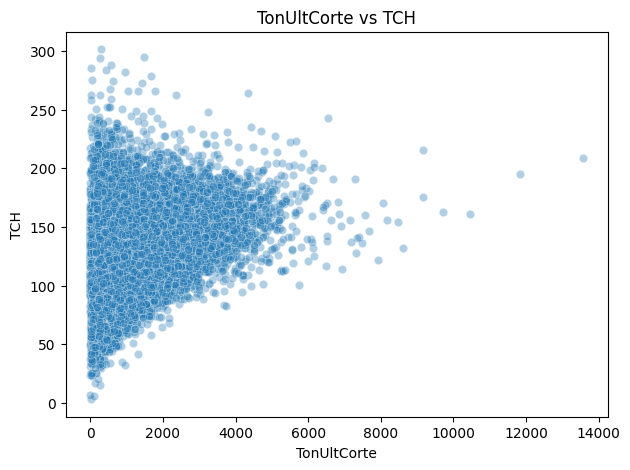

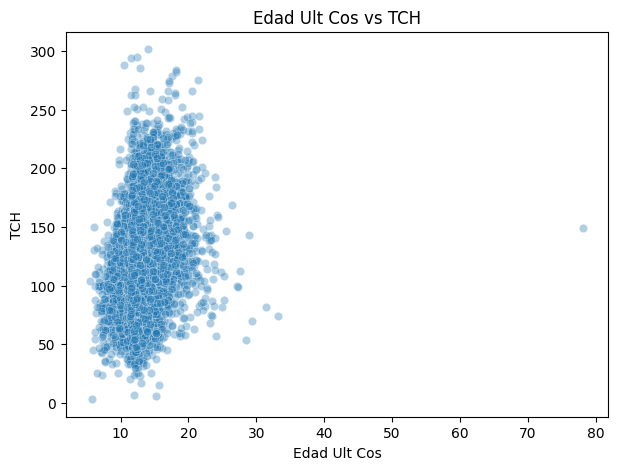

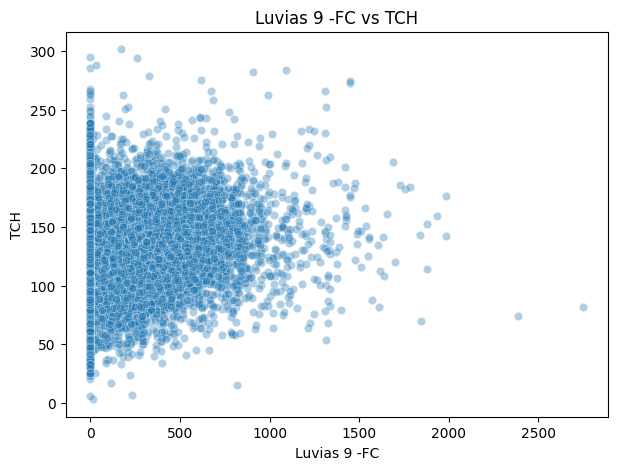

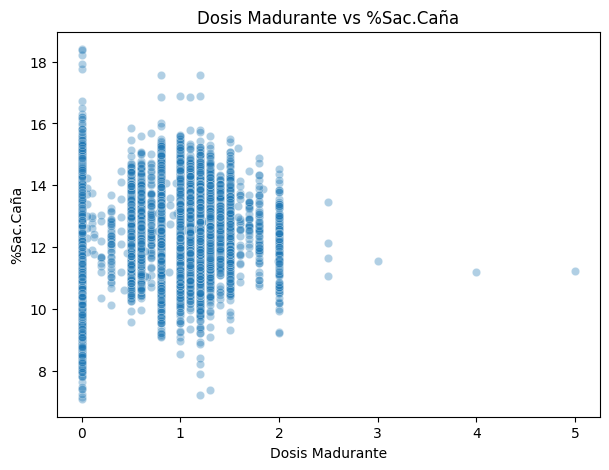

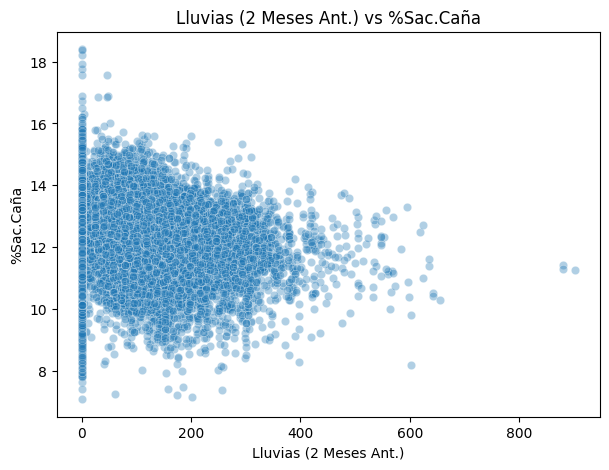

In [25]:

# 1) TonUltCorte vs TCH
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_reg_sacarosa, x='TonUltCorte', y='TCH', alpha=0.35)
plt.title('TonUltCorte vs TCH')
plt.xlabel('TonUltCorte')
plt.ylabel('TCH')
plt.show()

# 2) Edad Ult Cos vs TCH
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_reg_sacarosa, x='Edad Ult Cos', y='TCH', alpha=0.35)
plt.title('Edad Ult Cos vs TCH')
plt.xlabel('Edad Ult Cos')
plt.ylabel('TCH')
plt.show()

# 3) Luvias 9 -FC vs TCH
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_reg_sacarosa, x='Luvias 9 -FC', y='TCH', alpha=0.35)
plt.title('Luvias 9 -FC vs TCH')
plt.xlabel('Luvias 9 -FC')
plt.ylabel('TCH')
plt.show()

# 4) Dosis Madurante vs %Sac.Caña
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_reg_sacarosa, x='Dosis Madurante', y='%Sac.Caña', alpha=0.35)
plt.title('Dosis Madurante vs %Sac.Caña')
plt.xlabel('Dosis Madurante')
plt.ylabel('%Sac.Caña')
plt.show()

# 5) Lluvias (2 Meses Ant.) vs %Sac.Caña
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_reg_sacarosa, x='Lluvias (2 Meses Ant.)', y='%Sac.Caña', alpha=0.35)
plt.title('Lluvias (2 Meses Ant.) vs %Sac.Caña')
plt.xlabel('Lluvias (2 Meses Ant.)')
plt.ylabel('%Sac.Caña')
plt.show()



Interpretacion

### Variables categoricas


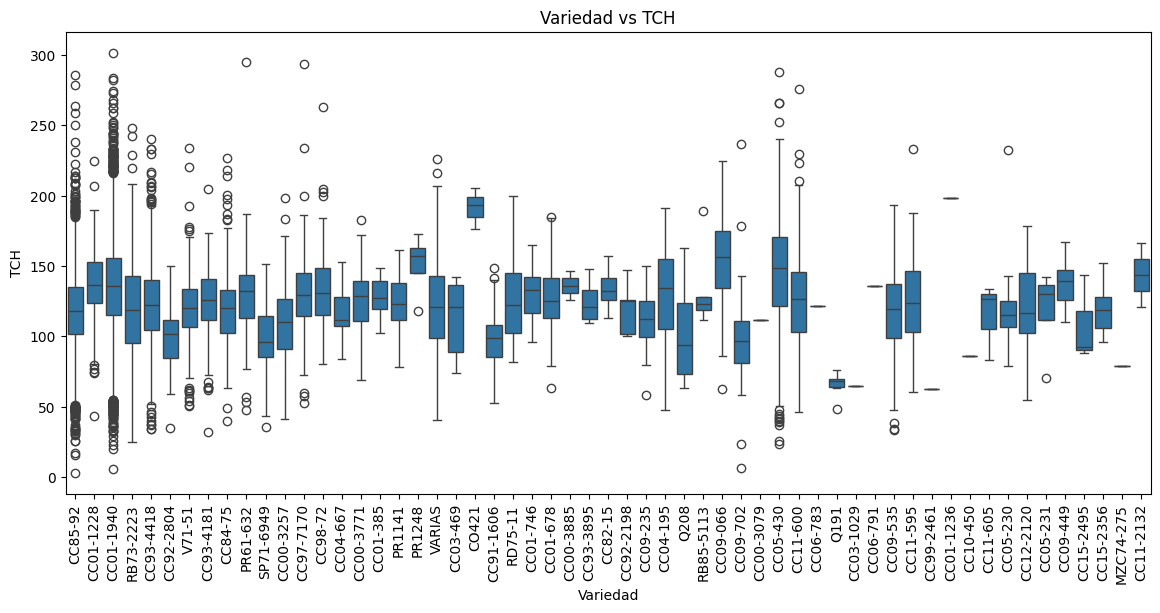

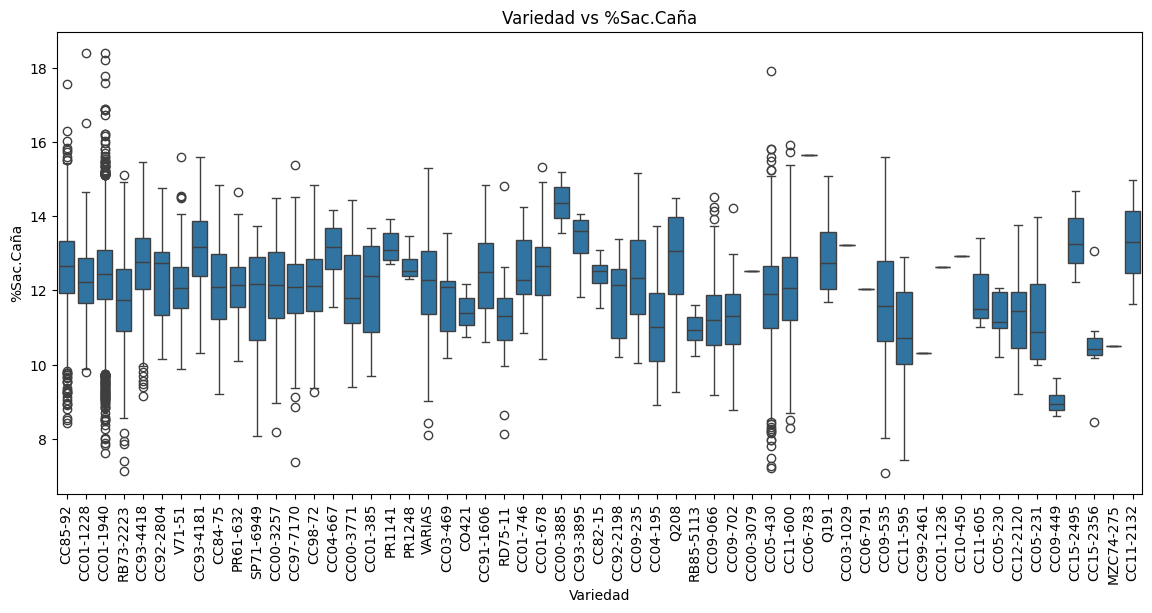

In [26]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df_reg_sacarosa, x='Variedad', y='TCH')
plt.title('Variedad vs TCH')
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(14,6))
sns.boxplot(data=df_reg_sacarosa, x='Variedad', y='%Sac.Caña')
plt.title('Variedad vs %Sac.Caña')
plt.xticks(rotation=90)
plt.show()

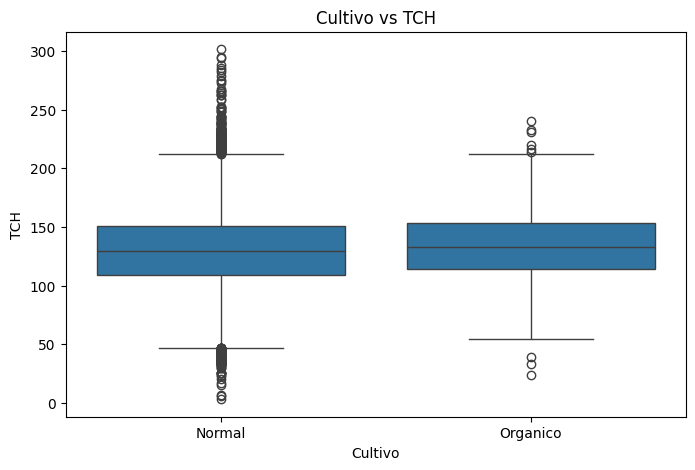

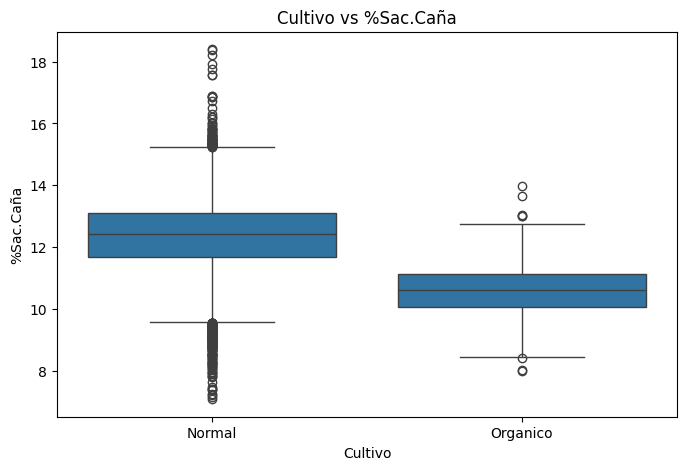

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_reg_sacarosa, x='Cultivo', y='TCH')
plt.title('Cultivo vs TCH')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df_reg_sacarosa, x='Cultivo', y='%Sac.Caña')
plt.title('Cultivo vs %Sac.Caña')
plt.show()

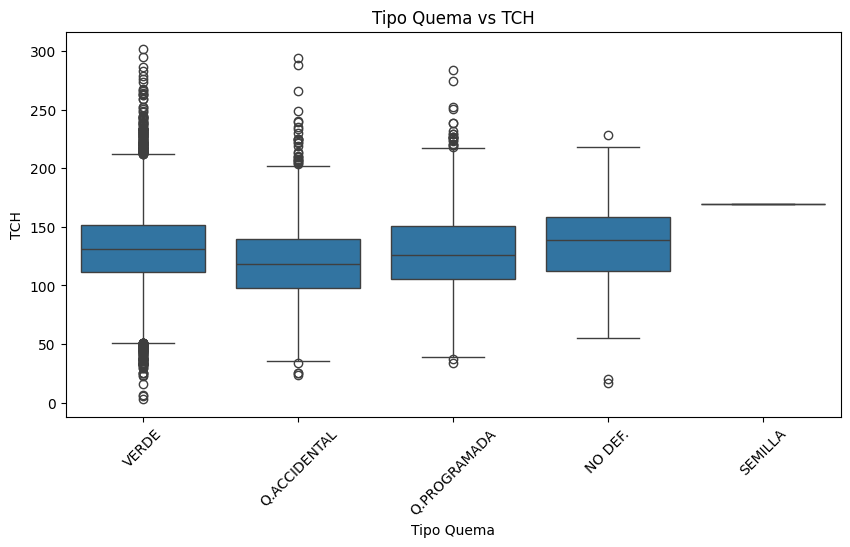

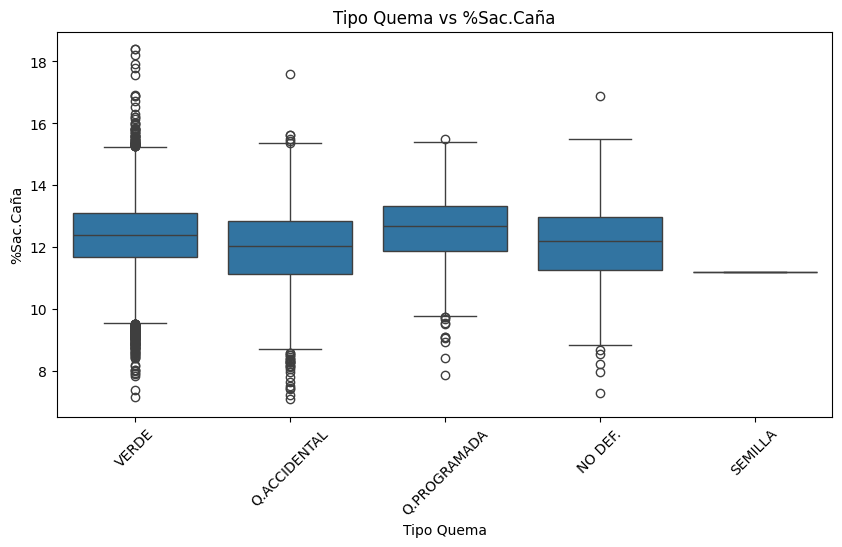

In [31]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_reg_sacarosa, x='Tipo Quema', y='TCH')
plt.title('Tipo Quema vs TCH')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=df_reg_sacarosa, x='Tipo Quema', y='%Sac.Caña')
plt.title('Tipo Quema vs %Sac.Caña')
plt.xticks(rotation=45)
plt.show()

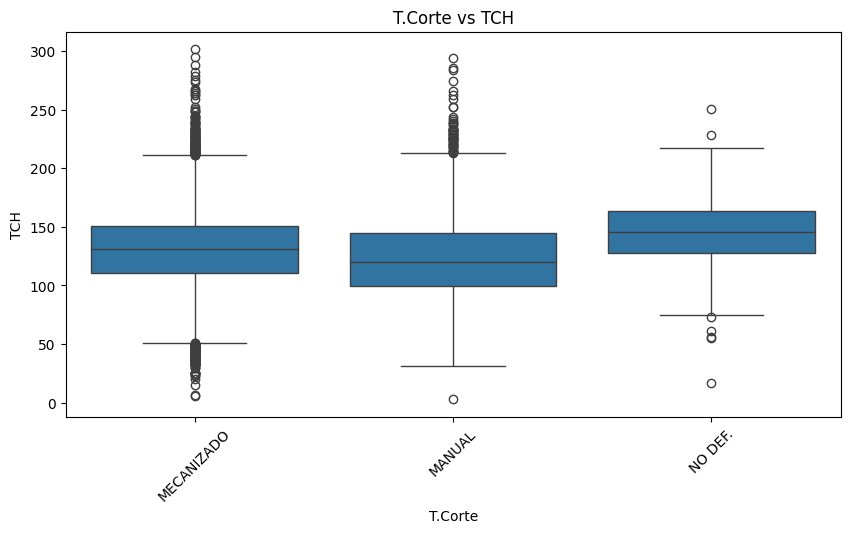

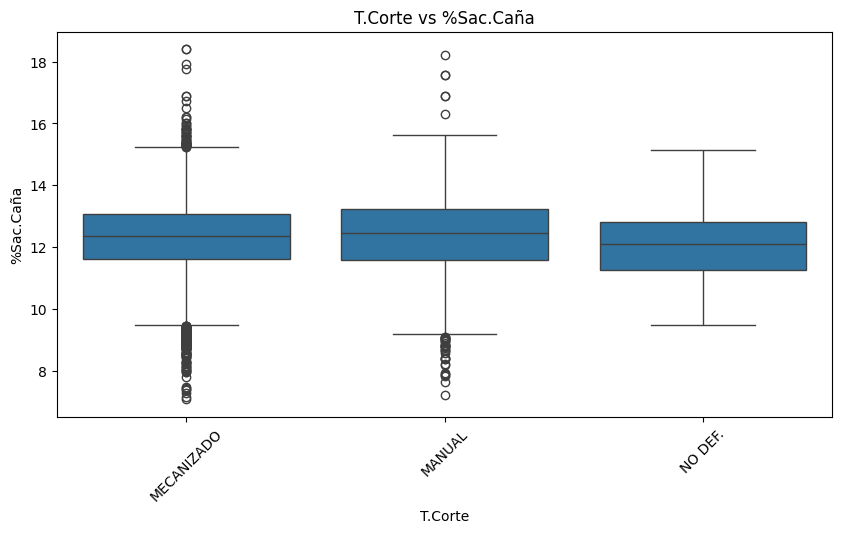

In [32]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_reg_sacarosa, x='T.Corte', y='TCH')
plt.title('T.Corte vs TCH')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=df_reg_sacarosa, x='T.Corte', y='%Sac.Caña')
plt.title('T.Corte vs %Sac.Caña')
plt.xticks(rotation=45)
plt.show()

In [27]:
variables_clf = [
    'variedad',
    'edad',
    'cortes',
    'lluvias',
    'grupo_tenencia',
    'pct_diatrea'
]

print("Variables predictoras clasificación:", variables_clf)

Variables predictoras clasificación: ['variedad', 'edad', 'cortes', 'lluvias', 'grupo_tenencia', 'pct_diatrea']


**¿Qué variables se seleccionan en clasificación y por qué?**

Para clasificación se eligieron:
variedad: representa diferencias genéticas del cultivo.
edad: influye sobre el nivel de desarrollo y rendimiento.
cortes: el número de cortes afecta el vigor de la caña y su productividad.
lluvias: refleja disponibilidad hídrica.
grupo_tenencia: puede asociarse con condiciones de manejo y tipo de explotación.
pct_diatrea: indicador fitosanitario, relevante para pérdidas de rendimiento.

**Variables descartadas en clasificación**

Se descartan:
NOME, FAZ, TAL: identificadores o referencias administrativas.
TCH y sacarosa como predictores: no deben entrar en X porque se usarán para construir la variable objetivo Clase; incluirlas produciría fuga de información.
producto y madurada podrían explorarse, pero se prefirió un conjunto más compacto y explicable para el modelo inicial.

In [28]:
# Crear target de clasificación usando TCH y sacarosa
df_clf['Clase'] = np.where(
    (df_clf['TCH'] > df_clf['TCH'].median()) &
    (df_clf['sacarosa'] > df_clf['sacarosa'].median()),
    'Alta',
    'Baja'
)

print(df_clf['Clase'].value_counts())

Clase
Baja    1769
Alta     418
Name: count, dtype: int64


En clasificación, la variable objetivo no viene dada directamente. Por eso se construye Clase a partir de TCH y sacarosa, clasificando como Alta los casos con rendimiento y calidad por encima de la mediana, y como Baja el resto.

**¿Qué estrategia de imputación se propone?**

**Para regresión:**
Variables numéricas con pocos faltantes: imputación por mediana, porque es robusta frente a outliers.
Variables categóricas con pocos faltantes: imputación por moda.
Dosis Madurante: si desde el negocio se interpreta que vacío equivale a “no aplicado”, puede imputarse con 0.
Variables con más del 50% de faltantes: descartar, ya que imputarlas introduciría demasiada incertidumbre.
Variables climáticas o de contexto: idealmente podrían imputarse por medias agrupadas por Zona, Período o Codigo Estacion, si se quisiera un tratamiento más fino.

**Para clasificación:**
Como las variables seleccionadas no presentan faltantes, no se requiere imputación para el conjunto base del modelo. Si aparecieran nulos en una versión posterior:
numéricas: mediana
categóricas: moda

**Qué hacer con variables con alto porcentaje de datos faltantes?**

Es preferible descartarlas cuando el porcentaje de faltantes es muy alto, especialmente por encima de 50%. Imputarlas conlleva un alto grado de incertidumbre y puede empeorar la calidad del análisis y del modelo. En regresión esto aplica a varias variables de fertilización y clima de baja cobertura.

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df_reg_eda[['Edad Ult Cos', 'Dist Km', 'Dosis Madurante', 'Semanas mad.']].copy()

X_vif = X_vif.dropna()

X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)

## Preparación de Datos para Clasificación

A partir de aquí usamos las funciones de `src/preprocessing.py` para:
1. **Imputar** valores nulos con reglas de negocio.
2. **Crear la variable objetivo** en tres clases balanceadas (`Bajo`, `Medio`, `Alto`) usando `TCH`.
3. **Codificar** las variables categóricas.
4. **Exportar** el dataset limpio a `data/processed/datos_limpios_modelo.csv`.

In [ ]:
import sys
import os
sys.path.append(os.path.abspath('..'))

from src.preprocessing import imputar_datos, create_target_classes, apply_label_encoder


In [ ]:
# Variables seleccionadas para clasificación ~ predictores agrónomicos
variables_clf = [
    'variedad',
    'edad',
    'cortes',
    'lluvias',
    'grupo_tenencia',
    'pct_diatrea',
    'dosismad',   # dosismad se imputará con 0 ~ regla de negocio
    'semsmad',
    'me',
    'vejez',
]

# Target y columnas sensibles que NO van como predictores
target_col = 'TCH'

# Subconjunto del dataset original (predictores + target)
cols_to_keep = variables_clf + [target_col, 'sacarosa']
df_clf_model = df_clf[cols_to_keep].copy()

print(f"Shape antes de imputar: {df_clf_model.shape}")
print(f"Nulos antes:\n{df_clf_model.isnull().sum()[df_clf_model.isnull().sum() > 0]}")

# Imputación con reglas de negocio
df_clf_model = imputar_datos(df_clf_model)

print(f"\nNulos después de imputar: {df_clf_model.isnull().sum().sum()}")


In [ ]:
# Crear variable objetivo en 3 clases balanceadas
df_clf_model = create_target_classes(df_clf_model, target_col='TCH')
print("Distribución de clases:")
print(df_clf_model['Clase_Objetivo'].value_counts())

# Codificación de variables categóricas con LabelEncoder
cat_cols = ['variedad']
df_clf_model, encoders = apply_label_encoder(df_clf_model, cat_cols)

print(f"\nShape final del dataset de modelado: {df_clf_model.shape}")
print(df_clf_model.dtypes)


In [ ]:
import os

# Ruta de salida
output_path = PROCESSED_DATA_PATH  # ya definida en la celda de configuración inicial

# Asegurar que el directorio existe
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Exportar
df_clf_model.to_csv(output_path, index=False)
print(f"Dataset limpio guardado en: {output_path}")
print(f"   Filas: {df_clf_model.shape[0]} | Columnas: {df_clf_model.shape[1]}")
print(f"   Columnas: {list(df_clf_model.columns)}")
